In [1]:
import scipy.io
import numpy as np
import os
import random
dsopt_name = "Cshape_bottom"

In [2]:
folder_path = os.path.join(os.getcwd(),"datasets")
if os.path.isdir(folder_path):
    print("Directory exists")
else:
    print("Run dsopt_dataset.sh to get the dataset")
path_name = os.path.join(folder_path, "3D_" + dsopt_name + ".mat")

Directory exists


In [3]:
if os.path.exists(path_name):
    mat = scipy.io.loadmat(path_name)
else:
    print("Dataset not found!")

In [4]:
demos = np.squeeze(mat["data"])

In [5]:
demo_new = demos * 10

In [7]:
demos[0]

array([[-6.71552492e-01, -6.71535239e-01, -6.71515760e-01, ...,
        -6.90405598e-01, -6.90404505e-01, -6.90404337e-01],
       [ 5.67067168e-02,  5.67158807e-02,  5.67312599e-02, ...,
         5.93914610e-02,  5.94360377e-02,  5.94720403e-02],
       [ 3.46260851e-02,  3.45991087e-02,  3.45680290e-02, ...,
         3.62515590e-01,  3.62501379e-01,  3.62486004e-01],
       [ 1.73370196e-03,  1.97114753e-03,  2.19372231e-03, ...,
         3.97775573e-04,  1.92325645e-04,  0.00000000e+00],
       [ 1.29597108e-03,  1.67305431e-03,  2.12698099e-03, ...,
         3.81672328e-03,  2.29808336e-03,  0.00000000e+00],
       [-2.70249487e-03, -3.11857398e-03, -3.50153974e-03, ...,
        -2.09026056e-03, -1.28855252e-03,  0.00000000e+00]])

In [6]:
demo_new[0]

array([[-6.71552492e+00, -6.71535239e+00, -6.71515760e+00, ...,
        -6.90405598e+00, -6.90404505e+00, -6.90404337e+00],
       [ 5.67067168e-01,  5.67158807e-01,  5.67312599e-01, ...,
         5.93914610e-01,  5.94360377e-01,  5.94720403e-01],
       [ 3.46260851e-01,  3.45991087e-01,  3.45680290e-01, ...,
         3.62515590e+00,  3.62501379e+00,  3.62486004e+00],
       [ 1.73370196e-02,  1.97114753e-02,  2.19372231e-02, ...,
         3.97775573e-03,  1.92325645e-03,  0.00000000e+00],
       [ 1.29597108e-02,  1.67305431e-02,  2.12698099e-02, ...,
         3.81672328e-02,  2.29808336e-02,  0.00000000e+00],
       [-2.70249487e-02, -3.11857398e-02, -3.50153974e-02, ...,
        -2.09026056e-02, -1.28855252e-02,  0.00000000e+00]])

In [72]:
demo = np.array([demos[i] for i in range(demos.shape[0])])

<ipython-input-72-2a5adbf93972>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  demo = np.array([demos[i] for i in range(demos.shape[0])])


ValueError: could not broadcast input array from shape (6,489) into shape (6,)

In [77]:
demos.shape

(15,)

In [81]:
init_min = (np.min([demos[i].pos[:,0] for i in range(15)], axis=0)/pos_scaling
init_min = np.where(init_min < -1, -1, init_min)
init_max = (np.max([demos[i].pos[:,0] for i in range(15)], axis=0)/pos_scaling 
init_max = np.where(init_max > 1, 1, init_max)

SyntaxError: invalid syntax (<ipython-input-81-89b81141b0ce>, line 2)

In [92]:
init_min = np.min([demos[i][:3,0] for i in range(15)], axis=0)
init_min

array([-0.76586871, -0.19240578,  0.01663736])

In [57]:
np.mean([demos[i][:3, 0] for i in range(15)], axis=0)

array([-0.64959497,  0.02684966,  0.04097955])

In [19]:
demos[7].shape

(6, 345)

In [13]:
# Divide the data into training and testing
total_demos = len(demos)
dim_in = 3
N = demos[0]
train_size = int(0.75 * total_demos) # 5/7 datasets are used for training
train_indices = random.sample(range(total_demos), train_size)
test_indices = list(set(range(total_demos)) - set(train_indices))
X_train = np.concatenate([demos[i][:3] for i in train_indices], axis=1).T
X_test = np.concatenate([demos[i][:3] for i in test_indices], axis=1).T
y_train = np.concatenate([demos[i][3:] for i in train_indices], axis=1).T
y_test = np.concatenate([demos[i][3:] for i in test_indices], axis=1).T 

In [15]:
X_train.shape

(4760, 3)

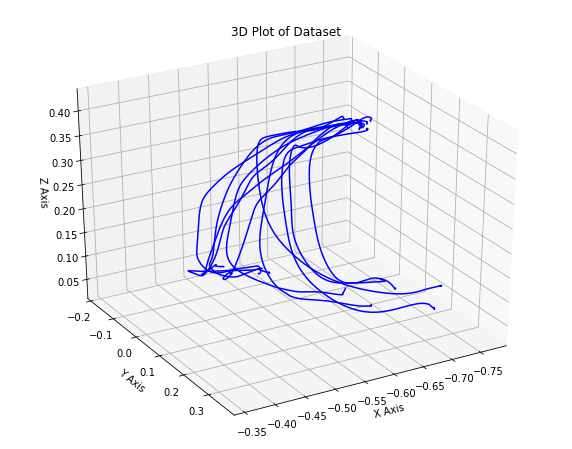

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

# Create a figure and 3D axes
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
for i in train_indices:
    ax.plot3D(demos[i][0,:], demos[i][1,:], demos[i][2,:], 'blue')

# Add labels and title
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Plot of Dataset')

# Adjust viewing angle
ax.view_init(elev=30, azim=60)

# Show the plot
plt.show()

In [ ]:
# Divide the data into training and testing
self.total_demos = len(self.demos)
self.dim_in = 3
train_size = int(0.75 * self.total_demos) # 5/7 datasets are used for training
train_indices = random.sample(range(self.total_demos), train_size)
test_indices = list(set(range(self.total_demos)) - set(train_indices))
self.X_train = np.concatenate([self.demos[i][:3] for i in train_indices], axis=1).T
self.X_test = np.concatenate([self.demos[i][:3] for i in test_indices], axis=1).T
self.y_train = np.concatenate([self.demos[i][3:] for i in train_indices], axis=1).T
self.y_test = np.concatenate([self.demos[i][3:] for i in test_indices], axis=1).T 
# Convert to Pytorch Tensors
self.X_train = torch.tensor(self.X_train, dtype=torch.float32)
self.X_test = torch.tensor(self.X_test, dtype=torch.float32)
self.y_train = torch.tensor(self.y_train, dtype=torch.float32)
self.y_test = torch.tensor(self.y_test, dtype=torch.float32)  
assert self.X_train.shape[0] == self.y_train.shape[0], "Mismatch in number of samples between X_train and y_train"
assert self.X_test.shape[0] == self.y_test.shape[0], "Mismatch in number of samples between X_test and y_test" 
train_dataset = torch.utils.data.TensorDataset(self.X_train, self.y_train)
test_dataset = torch.utils.data.TensorDataset(self.X_test, self.y_test)
batch_size = self.config["model_f"]["batch_size"]
self.train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=self.seed_worker, generator=self.g)
self.test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, worker_init_fn=self.seed_worker, generator=self.g)

In [26]:
tot_data = []
for i in range(np_data.shape[0]):
    

(15, 1)

# Neural ODE

In [26]:
import time

import diffrax
import equinox as eqx  # https://github.com/patrick-kidger/equinox
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import optax  # https://github.com/deepmind/optax
from sklearn.preprocessing import MinMaxScaler
from scipy import interpolate
import numpy as np

In [75]:
demos[0].pos.shape

(2, 1000)

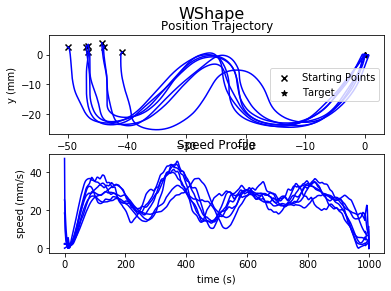

In [73]:
import pyLasaDataset as lasa

# DataSet object has all the LASA handwriting data files
# as attributes, eg:
angle_data = lasa.DataSet.Angle
sine_data = lasa.DataSet.Sine
Leaf_2_data = lasa.DataSet.Leaf_2
CShape_data = lasa.DataSet.CShape
DoubleBendedLine = lasa.DataSet.DoubleBendedLine

data = lasa.DataSet.WShape


# Each Data object has attributes dt and demos (For documentation,
# refer original dataset repo:
# https://bitbucket.org/khansari/lasahandwritingdataset/src/master/Readme.txt)
dt = data.dt
demos = data.demos # list of 7 Demo objects, each corresponding to a
                         # repetition of the pattern


# Each Demo object in demos list will have attributes pos, t, vel, acc
# corresponding to the original .mat format described in
# https://bitbucket.org/khansari/lasahandwritingdataset/src/master/Readme.txt
demo_0 = demos[1]
pos = demo_0.pos # np.ndarray, shape: (2,2000)
vel = demo_0.vel # np.ndarray, shape: (2,2000)
acc = demo_0.acc # np.ndarray, shape: (2,2000)
t = demo_0.t # np.ndarray, shape: (1,2000)


# To visualise the data (2D position and velocity) use the plot_model utility
lasa.utilities.plot_model(data) # give any of the available

In [28]:
class Func(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        initializer = jnn.initializers.orthogonal()
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.tanh,
            key=key,
        )
        model_key = key
        key_weights = jrandom.split(model_key, depth+1)

        for i in range(depth+1):
          where = lambda m: m.layers[i].weight
          shape = self.mlp.layers[i].weight.shape
          self.mlp = eqx.tree_at(where, self.mlp, replace=initializer(key_weights[i], shape, dtype = jnp.float32))

    @eqx.filter_jit
    def __call__(self, t, y, args):

        return self.mlp(y)

In [29]:
class Funcd(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        initializer = jnn.initializers.orthogonal()
        self.mlp = eqx.nn.MLP(
            in_size=2*data_size,
            out_size=2*data_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.tanh,
            key=key,
        )
        model_key = key
        key_weights = jrandom.split(model_key, depth+1)

        for i in range(depth+1):
          where = lambda m: m.layers[i].weight
          shape = self.mlp.layers[i].weight.shape
          self.mlp = eqx.tree_at(where, self.mlp, replace=initializer(key_weights[i], shape, dtype = jnp.float32))

    @eqx.filter_jit
    def __call__(self, t, yd, args):

        return self.mlp(yd)
        # return self.mlp(jnp.concatenate([yd, jnp.array([t])]))

In [31]:
class NeuralODE(eqx.Module):
    func: Func

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Func(data_size, width_size, depth, key=key)

    def __call__(self, ts, y0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

In [32]:
class NeuralODEd(eqx.Module):
    func: Funcd

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Funcd(data_size, width_size, depth, key=key)

    @eqx.filter_jit
    def __call__(self, ts, yd0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=yd0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

In [44]:
ndemos = len(demos)
T = demos[0].t.shape[-1]
pos_all = []
vel_all = []
for i in range(ndemos):
  pos_all.append((demos[i].pos).T)
  vel_all.append((demos[i].vel).T)
posn = jnp.array(pos_all)
veln = jnp.array(vel_all)
tn =  jnp.array(t.T).reshape(T)
ys_all_n = jnp.concatenate((posn,veln),axis=2)

nsamples = 1000
ts = t[0]/t[0, -1]
ts_new = jnp.linspace(0, 1, nsamples)

dim = posn.shape[2]

traj_process = jnp.zeros((ndemos, nsamples, dim))
vel_process = jnp.zeros((ndemos, nsamples, dim))

traj_all_t_norm = []
# time_all_process = jnp.zeros((traj_c, nsamples))

seed = 1385

key = jax.random.PRNGKey(seed)
scale_state = 1

key_trajs = jax.random.split(key, num=ndemos)

for i in range(ndemos):
  key_dim = jax.random.split(key_trajs[i], num=dim)
  for j in range(dim):
    f = interpolate.interp1d(ts, posn[i, :, j])
    f_vel = interpolate.interp1d(ts, veln[i, :, j])
    # f = interpolate.interp1d(time_all[i][:, 0], traj_all[i][:, j])
    # ts_new = np.linspace(time_all[i][0, 0], time_all[i][-1, 0], nsamples)
    # time_all_process = time_all_process.at[i].set(ts_new)
    traj_new = f(ts_new)
    vel_new = f_vel(ts_new)
    traj_process = traj_process.at[i, :, j].set(scale_state*traj_new)
    vel_process = vel_process.at[i, :, j].set(scale_state*vel_new)

## Train_Test_split

nTD = 4
traj_train = traj_process[1:nTD]
vel_train = vel_process[1:nTD]

traj_test = traj_process[nTD:]
vel_test = vel_process[nTD:]

## Multi_models

# train_indx = [0, 2, 4, 6]
# nTD = len(train_indx)
# traj_train = jnp.zeros((len(train_indx), nsamples, dim))
# vel_train = jnp.zeros((len(train_indx), nsamples, dim))
# c=0

# for i in train_indx:
#   traj_train = traj_train.at[c].set(traj_process[i])
#   vel_train = vel_train.at[c].set(vel_process[i])
#   c += 1

# test_indx = [1, 3, 5]
# traj_test = jnp.zeros((len(test_indx), nsamples, dim))
# vel_test = jnp.zeros((len(test_indx), nsamples, dim))
# c=0

# for i in test_indx:
#   traj_test = traj_test.at[c].set(traj_process[i])
#   vel_test = vel_test.at[c].set(vel_process[i])
#   c += 1

traj_all_train = jnp.concatenate((traj_train, vel_train), axis=2)
traj_all_test = jnp.concatenate((traj_test, vel_test), axis=2)

In [45]:
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jrandom.permutation(key, indices)
        (key,) = jrandom.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size


In [50]:
def main(
    dataset_size=nTD,
    batch_size=int(nTD/2),
    lr_strategy=(5e-4,),
    steps_strategy=(10000,),
    length_strategy=(1,),
    width_size=64,
    depth=3,
    seed=1000,
    plot=True,
    print_every=100,
    save_every=500,
):
    key = jrandom.PRNGKey(seed)
    data_key, model_key, loader_key = jrandom.split(key, 3)

    ys = traj_train
    ts = tn
    ys_dot = vel_train
    ys_all = traj_all_train

    # ys = posn[:nTD]
    # ts = tn
    # ys_dot = veln[:nTD]
    # ys_all = ys_all_n[:nTD]

    # file_name = "/content/drive/MyDrive/Colab Notebooks/Neural ODE/LASA_models/CoRL_2023/WShape_checkpoint.eqx"

    # ts, ys, ys_dot = get_data(dataset_size, key=data_key)

    # yst = jnp.copy(ys)

    # scaler = MinMaxScaler()
    # for i in range(dataset_size):
    #   scaler.fit(ys[i])
    #   ysti = scaler.transform(ys[i])
    #   yst = yst.at[i].set(ysti)
    #   # yst = jnp.expand_dims(yst, axis = 0)
    # scaler.fit(ts.reshape(-1,1))
    # tst = scaler.transform(ts.reshape(-1,1))
    # tst = tst.reshape(-1,)

    # ys = yst
    # ts = tst

    _, length_size, data_size = ys.shape

    model = NeuralODE(data_size, width_size, depth, key=model_key)

    # Training loop like normal.
    #
    # Only thing to notice is that up until step 500 we train on only the first 10% of
    # each time series. This is a standard trick to avoid getting caught in a local
    # minimum.

    @eqx.filter_value_and_grad
    def grad_loss(model, ti, yi):
        y_pred = jax.vmap(model, in_axes=(None, 0))(ti, yi[:, 0])
        f = lambda t, z: model.func(t, z, _)
        # y_dot_pred = jax.vmap(jax.vmap(f, in_axes = (0, 0)), in_axes=(None, 0))(ti, yi)
        loss = jnp.mean((yi - y_pred) ** 2)
        # loss = jnp.mean((y_dot_pred - yi_dot)**2)
        return loss

    @eqx.filter_jit
    def make_step(ti, yi, model, opt_state):
        loss, grads = grad_loss(model, ti, yi)
        updates, opt_state = optim.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    time_all = 0

    for lr, steps, length in zip(lr_strategy, steps_strategy, length_strategy):
        decay_scheduler = optax.cosine_decay_schedule(lr, decay_steps=steps, alpha=0.95)
        # decay_scheduler = optax.piecewise_constant_schedule(init_value=lr, boundaries_and_scales={int(steps*0.25):0.5, int(steps*0.5):0.5, int(steps*0.75):0.5})
        decay_scheduler = optax.exponential_decay(init_value=lr, transition_steps=steps, decay_rate=0.98, transition_begin=int(steps*0.25), staircase=False)
        # decay_scheduler = optax.linear_schedule(init_value=lr, end_value=0.005*lr, transition_steps=steps, transition_begin=int(steps*0.25))
        optim = optax.adabelief(learning_rate=decay_scheduler)
        opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))
        _ts = ts[: int(length_size * length)]
        _ys = ys[:, : int(length_size * length)]
        # _ys_dot = ys_dot[:, : int(length_size * length)]
        _ys_all = ys_all_n[:, :int(length_size * length)]
        ## Single trajectory
        # for step in range(steps):
        #   start = time.time()
        #   loss, model, opt_state = make_step(_ts, _ys, _ys_dot, model, opt_state)
        #   end = time.time()
        #   if (step % print_every) == 0 or step == steps - 1:
        #     print(f"Step: {step}, Loss: {loss}, Computation time: {end - start}")
        ## Batches
        for step, (yi,) in zip(
            range(steps), dataloader((_ys,), batch_size, key=loader_key)
        ):
            start = time.time()
            loss, model, opt_state = make_step(_ts, yi, model, opt_state)
            end = time.time()
            time_all += end - start
            if (step % print_every) == 0 or step == steps - 1:
                print(f"Step: {step}, Loss: {loss}, Computation time: {end - start}")
            # if (step % save_every) == 0 or step == steps - 1:
            #   eqx.tree_serialise_leaves(file_name, model)

    # if plot:
    #     plt.plot(ts, ys[0, :, 0], c="dodgerblue", label="Real")
    #     plt.plot(ts, ys[0, :, 1], c="dodgerblue")
    #     model_y = model(ts, ys[0, 0])
    #     plt.plot(ts, model_y[:, 0], c="crimson", label="Model")
    #     plt.plot(ts, model_y[:, 1], c="crimson")
    #     plt.legend()
    #     plt.tight_layout()
    #     plt.savefig("neural_ode.png")
    #     plt.show()

    return ts, ys, model, time_all

In [51]:
ts, ys, model, time_all = main()

Step: 0, Loss: 461.9473876953125, Computation time: 3.3573999404907227
Step: 100, Loss: 56.136558532714844, Computation time: 0.005376100540161133
Step: 200, Loss: 43.86167907714844, Computation time: 0.005070924758911133
Step: 300, Loss: 39.41489028930664, Computation time: 0.007047176361083984
Step: 400, Loss: 31.45694351196289, Computation time: 0.005894660949707031
Step: 500, Loss: 26.312477111816406, Computation time: 0.00643467903137207
Step: 600, Loss: 26.920513153076172, Computation time: 0.0070645809173583984
Step: 700, Loss: 25.464017868041992, Computation time: 0.007768154144287109
Step: 800, Loss: 25.174501419067383, Computation time: 0.008064508438110352
Step: 900, Loss: 26.4800968170166, Computation time: 0.00822758674621582
Step: 1000, Loss: 22.007104873657227, Computation time: 0.008221864700317383
Step: 1100, Loss: 23.70408821105957, Computation time: 0.008237838745117188
Step: 1200, Loss: 22.798015594482422, Computation time: 0.007657527923583984
Step: 1300, Loss: 24.

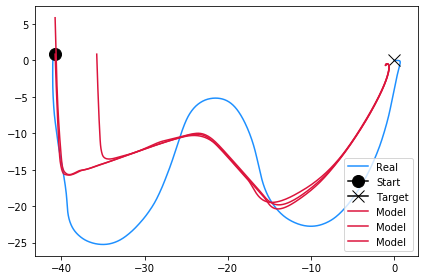

In [52]:
train_indx = 0
plt.plot(posn[train_indx, :, 0], posn[train_indx, :, 1], c="dodgerblue", label="Real")
plt.plot(posn[train_indx, 0, 0], posn[train_indx, 0, 1], c="black", marker='o', markersize = '12', label="Start")
plt.plot(posn[train_indx, -1, 0], posn[train_indx, -1, 1], c="black", marker='x', markersize = '12', label="Target")
model_y = model(2*ts, posn[train_indx, 0])
plt.plot(model_y[:, 0], model_y[:, 1], c="crimson", label="Model")
model_y = model(2*ts, posn[train_indx, 0] + np.array([0, 5]))
plt.plot(model_y[:, 0], model_y[:, 1], c="crimson", label="Model")
model_y = model(2*ts, posn[train_indx, 0] + np.array([5, 0]))
plt.plot(model_y[:, 0], model_y[:, 1], c="crimson", label="Model")
plt.legend()
plt.tight_layout()
plt.savefig("neural_ode.png")
plt.show()